# Проект: Российский кинопрокат


**Описание проекта:**

Заказчик этого исследования — Министерство культуры Российской Федерации. 
Вам нужно изучить рынок российского кинопроката и выявить текущие тренды. Уделите внимание фильмам, которые получили государственную поддержку. Попробуйте ответить на вопрос, насколько такие фильмы интересны зрителю. 
Вы будете работать с данными, опубликованными на портале открытых данных Министерства культуры. Набор данных содержит информацию о прокатных удостоверениях, сборах и государственной поддержке фильмов, а также информацию с сайта КиноПоиск. 

**Описание данных:**
- title — название фильма;
- puNumber — номер прокатного удостоверения;
- show_start_date — дата премьеры фильма;
- type — тип фильма;
- film_studio — студия-производитель;
- production_country — страна-производитель;
- director — режиссёр;
- producer — продюсер;
- age_restriction — возрастная категория;
- refundable_support — объём возвратных средств государственной поддержки;
- nonrefundable_support — объём невозвратных средств государственной поддержки;
- financing_source — источник государственного финансирования;
- budget — общий бюджет фильма;
- ratings — рейтинг фильма на КиноПоиске;
- genres — жанр фильма.

## Загрузка

In [1]:
# импорт библиотек
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from datetime import datetime
import plotly.graph_objects as go

In [2]:
pd.set_option('display.max_columns', None)

movies = pd.read_csv('https://code.s3.yandex.net/datasets/mkrf_movies.csv')
shows = pd.read_csv('https://code.s3.yandex.net/datasets/mkrf_shows.csv')

In [3]:
movies.shape
movies.info()

display(movies.head(10))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7486 entries, 0 to 7485
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   title                  7486 non-null   object 
 1   puNumber               7486 non-null   object 
 2   show_start_date        7486 non-null   object 
 3   type                   7486 non-null   object 
 4   film_studio            7468 non-null   object 
 5   production_country     7484 non-null   object 
 6   director               7477 non-null   object 
 7   producer               6918 non-null   object 
 8   age_restriction        7486 non-null   object 
 9   refundable_support     332 non-null    float64
 10  nonrefundable_support  332 non-null    float64
 11  budget                 332 non-null    float64
 12  financing_source       332 non-null    object 
 13  ratings                6519 non-null   object 
 14  genres                 6510 non-null   object 
dtypes: f

,title,puNumber,show_start_date,type,film_studio,production_country,director,producer,age_restriction,refundable_support,nonrefundable_support,budget,financing_source,ratings,genres
0,Открытый простор,221048915,2015-11-27T12:00:00.000Z,Художественный,"Тачстоун Пикчерз, Кобальт Пикчерз, Бикон Пикче...",США,Кевин Костнер,"Дэвид Валдес, Кевин Костнер, Джейк Эбертс",«18+» - запрещено для детей,NaN,NaN,NaN,NaN,7.2,"боевик,драма,мелодрама"
1,Особо важное задание,111013716,2016-09-13T12:00:00.000Z,Художественный,"Киностудия ""Мосфильм""",СССР,Е.Матвеев,NaN,«6+» - для детей старше 6 лет,NaN,NaN,NaN,NaN,6.6,"драма,военный"
2,Особо опасен,221038416,2016-10-10T12:00:00.000Z,Художественный,"Юниверсал Пикчерз, Кикстарт Продакшнз, Марк Пл...",США,Тимур Бекмамбетов,"Джим Лемли, Джейсон Нетер, Марк Е.Платт, Яйн Смит",«18+» - запрещено для детей,NaN,NaN,NaN,NaN,6.8,"фантастика,боевик,триллер"
3,Особо опасен,221026916,2016-06-10T12:00:00.000Z,Художественный,"Юниверсал Пикчерз, Кикстарт Продакшнз, Марк Пл...",США,Тимур Бекмамбетов,"Джим Лемли, Джейсон Нетер, Марк Е.Платт, Яйн Смит",«18+» - запрещено для детей,NaN,NaN,NaN,NaN,6.8,"фантастика,боевик,триллер"
4,Особо опасен,221030815,2015-07-29T12:00:00.000Z,Художественный,"Юниверсал Пикчерз, Кикстарт Продакшнз, Марк Пл...",США,Тимур Бекмамбетов,"Джим Лемли, Джейсон Нетер, Марк Е.Платт, Яйн Смит",«18+» - запрещено для детей,NaN,NaN,NaN,NaN,6.8,"фантастика,боевик,триллер"
5,Остановился поезд,111013816,2016-09-13T12:00:00.000Z,Художественный,"Киностудия ""Мосфильм""",СССР,В.Абдрашитов,NaN,«6+» - для детей старше 6 лет,NaN,NaN,NaN,NaN,7.7,драма
6,Любовь и голуби,111007013,2013-10-18T12:00:00.000Z,Художественный,"Киностудия ""Мосфильм""",СССР,В.Меньшов,NaN,«12+» - для детей старше 12 лет,NaN,NaN,NaN,NaN,8.3,"мелодрама,комедия"
7,Любовь и сигареты,221074614,2014-12-29T12:00:00.000Z,Художественный,"Юнайтед Артистс, Грин Стрит Филмз, Айкон Интер...",США,Джон Туртурро,"Джон Пенотти, Джон Туртурро",«18+» - запрещено для детей,NaN,NaN,NaN,NaN,6.6,"мюзикл,мелодрама,комедия"
8,Отпетые мошенники.,121011416,2016-05-05T12:00:00.000Z,Художественный,"Пульсар Продюксьон, ТФ1 Фильм",Франция,Эрик Беснард,Патрис Леду,«18+» - запрещено для детей,NaN,NaN,NaN,NaN,8.0,"комедия,криминал"
9,Отпуск за свой счет,111019114,2014-12-01T12:00:00.000Z,Художественный,"Киностудия ""Мосфильм"", Телевидение ВНР","СССР, Венгрия",В.Титов,NaN,«12+» - для детей старше 12 лет,NaN,NaN,NaN,NaN,7.8,"мелодрама,комедия"


In [4]:
shows.shape  
shows.info()

display(shows.head(10))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3158 entries, 0 to 3157
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   puNumber    3158 non-null   int64  
 1   box_office  3158 non-null   float64
dtypes: float64(1), int64(1)
memory usage: 49.5 KB


,puNumber,box_office
0,111000113,2.450000e+03
1,111000115,6.104000e+04
2,111000116,1.530300e+08
3,111000117,1.226096e+07
4,111000118,1.636841e+08
5,111000119,4.293650e+06
6,111000212,2.000000e+02
7,111000216,3.555670e+05
8,111000313,7.100000e+02
9,111000314,1.607970e+06


Мы взяли данные из двух разных файлов (`mkrf_movies.csv` и `mkrf_shows.csv`) и провели их предварительный анализ. Теперь нам нужно обработать эти данные, проверить их на дубликаты и пустые значения и, если возможно, исправить ошибки для достижения максимально точных результатов. Прежде чем объединять датафреймы, необходимо изменить тип данных в столбце puNumber из `mkrf_movies`, потому что в настоящее время данные в этом столбце имеют строковый формат. Однако, в таблице `mkrf_shows` данные в том же столбце представлены в числовом виде. Следовательно, нам нужно изменить тип данных соответствующего столбца в таблице `mkrf_movies` и заменить имеющееся в нем буквенное значение.

## Предобработка данных

###  Проверка типов данных

In [5]:
# поменяем значения
movies.loc[movies['puNumber'] == 'нет', 'puNumber'] = 0
movies.query('puNumber == 0')

,title,puNumber,show_start_date,type,film_studio,production_country,director,producer,age_restriction,refundable_support,nonrefundable_support,budget,financing_source,ratings,genres
1797,Курбан-роман. (История с жертвой),0,2014-05-15T12:00:00.000Z,Художественный,"ФОНД ""ИННОВАЦИЯ""",Россия,С.Юзеев,М.Галицкая,«12+» - для детей старше 12 лет,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
# изменим тип данных
movies['puNumber'] = movies['puNumber'].astype('int32')
movies.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7486 entries, 0 to 7485
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   title                  7486 non-null   object 
 1   puNumber               7486 non-null   int32  
 2   show_start_date        7486 non-null   object 
 3   type                   7486 non-null   object 
 4   film_studio            7468 non-null   object 
 5   production_country     7484 non-null   object 
 6   director               7477 non-null   object 
 7   producer               6918 non-null   object 
 8   age_restriction        7486 non-null   object 
 9   refundable_support     332 non-null    float64
 10  nonrefundable_support  332 non-null    float64
 11  budget                 332 non-null    float64
 12  financing_source       332 non-null    object 
 13  ratings                6519 non-null   object 
 14  genres                 6510 non-null   object 
dtypes: f

In [7]:
# объединим датафреймы в один датасет
df = movies.merge(shows, on = 'puNumber', how = 'left')
print(df.info())
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7486 entries, 0 to 7485
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   title                  7486 non-null   object 
 1   puNumber               7486 non-null   int32  
 2   show_start_date        7486 non-null   object 
 3   type                   7486 non-null   object 
 4   film_studio            7468 non-null   object 
 5   production_country     7484 non-null   object 
 6   director               7477 non-null   object 
 7   producer               6918 non-null   object 
 8   age_restriction        7486 non-null   object 
 9   refundable_support     332 non-null    float64
 10  nonrefundable_support  332 non-null    float64
 11  budget                 332 non-null    float64
 12  financing_source       332 non-null    object 
 13  ratings                6519 non-null   object 
 14  genres                 6510 non-null   object 
 15  box_

,title,puNumber,show_start_date,type,film_studio,production_country,director,producer,age_restriction,refundable_support,nonrefundable_support,budget,financing_source,ratings,genres,box_office
0,Открытый простор,221048915,2015-11-27T12:00:00.000Z,Художественный,"Тачстоун Пикчерз, Кобальт Пикчерз, Бикон Пикче...",США,Кевин Костнер,"Дэвид Валдес, Кевин Костнер, Джейк Эбертс",«18+» - запрещено для детей,NaN,NaN,NaN,NaN,7.2,"боевик,драма,мелодрама",NaN
1,Особо важное задание,111013716,2016-09-13T12:00:00.000Z,Художественный,"Киностудия ""Мосфильм""",СССР,Е.Матвеев,NaN,«6+» - для детей старше 6 лет,NaN,NaN,NaN,NaN,6.6,"драма,военный",NaN
2,Особо опасен,221038416,2016-10-10T12:00:00.000Z,Художественный,"Юниверсал Пикчерз, Кикстарт Продакшнз, Марк Пл...",США,Тимур Бекмамбетов,"Джим Лемли, Джейсон Нетер, Марк Е.Платт, Яйн Смит",«18+» - запрещено для детей,NaN,NaN,NaN,NaN,6.8,"фантастика,боевик,триллер",NaN
3,Особо опасен,221026916,2016-06-10T12:00:00.000Z,Художественный,"Юниверсал Пикчерз, Кикстарт Продакшнз, Марк Пл...",США,Тимур Бекмамбетов,"Джим Лемли, Джейсон Нетер, Марк Е.Платт, Яйн Смит",«18+» - запрещено для детей,NaN,NaN,NaN,NaN,6.8,"фантастика,боевик,триллер",NaN
4,Особо опасен,221030815,2015-07-29T12:00:00.000Z,Художественный,"Юниверсал Пикчерз, Кикстарт Продакшнз, Марк Пл...",США,Тимур Бекмамбетов,"Джим Лемли, Джейсон Нетер, Марк Е.Платт, Яйн Смит",«18+» - запрещено для детей,NaN,NaN,NaN,NaN,6.8,"фантастика,боевик,триллер",NaN


In [10]:
# изменим формат времени 
df['show_start_date'] = pd.to_datetime(df['show_start_date'])
print(df['show_start_date'].head())

0   2015-11-27 12:00:00+00:00
1   2016-09-13 12:00:00+00:00
2   2016-10-10 12:00:00+00:00
3   2016-06-10 12:00:00+00:00
4   2015-07-29 12:00:00+00:00
Name: show_start_date, dtype: datetime64[ns, UTC]


### Проверка пропусков

In [11]:
df.isna().sum()

title                       0
puNumber                    0
show_start_date             0
type                        0
film_studio                18
production_country          2
director                    9
producer                  568
age_restriction             0
refundable_support       7154
nonrefundable_support    7154
budget                   7154
financing_source         7154
ratings                   967
genres                    976
box_office               4328
dtype: int64

#### Признак `film_studio`

In [12]:
df.query('film_studio.isna()')

,title,puNumber,show_start_date,type,film_studio,production_country,director,producer,age_restriction,refundable_support,nonrefundable_support,budget,financing_source,ratings,genres,box_office
1293,Stars in Shorts,121011114,2014-06-03 12:00:00+00:00,Художественный,NaN,"США, Великобритания","Роберт Фестингер, Руперт Френд, Джей Камен, Ни...","Татьяна Келли, Роберта Мунро, Руперт Френд, До...",«16+» - для детей старше 16 лет,NaN,NaN,NaN,NaN,7.3,комедия,NaN
4441,Мульт личности. Выпуск 5,214000410,2010-01-25 12:00:00+00:00,Художественный,NaN,NaN,NaN,NaN,«0+» - для любой зрительской аудитории,NaN,NaN,NaN,NaN,4.0,"мультфильм,комедия",NaN
6105,Значит любит,111013818,2018-08-10 12:00:00+00:00,Художественный,NaN,Россия,А.Краевский,Е.Щербакова,«18+» - запрещено для детей,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6181,Несейка. Младшая дочь,112007018,2018-09-01 12:00:00+00:00,Документальный,NaN,Россия,В.Марин,"Д.Якунин, Ф.Абрютин, О.Филонова",«6+» - для детей старше 6 лет,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6379,Ян Антонышев,112011818,2018-11-15 12:00:00+00:00,Документальный,NaN,Россия,Е.Окопная,Е.Герасимов,«12+» - для детей старше 12 лет,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6380,Ян Антонышев,112011918,2018-11-15 12:00:00+00:00,Документальный,NaN,Россия,Е.Окопная,Е.Герасимов,«12+» - для детей старше 12 лет,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6399,Доживем до каникул?..,111021918,2018-11-15 12:00:00+00:00,Художественный,NaN,Россия,Я.Хальпукова (псевдоним Яна Мартынец),Я.Хальпукова (псевдоним Яна Мартынец),«12+» - для детей старше 12 лет,NaN,NaN,NaN,NaN,NaN,NaN,41225.0
6485,До и После,112014418,2018-12-05 12:00:00+00:00,Документальный,NaN,Россия,А.Новокреповская,А.Новокреповская,«6+» - для детей старше 6 лет,NaN,NaN,NaN,NaN,6.9,"драма,криминал,детектив",NaN
6494,Калмыцкий геше Нгаванг Вангьял,113002018,2018-12-05 12:00:00+00:00,Научно-популярный,NaN,Россия,И.Долгина,И.Долгина,«12+» - для детей старше 12 лет,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6497,Мой папа Чингисхан,112014918,2018-12-06 12:00:00+00:00,Документальный,NaN,Россия,А.Сайфуллина,А.Сайфуллина,«12+» - для детей старше 12 лет,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [13]:
# удалим пропуски, так как их мало
df.dropna(subset = ['film_studio'], inplace = True)
df['film_studio'].isna().sum()

0

#### Признак `production_country`

In [14]:
df.query('production_country.isna()')

,title,puNumber,show_start_date,type,film_studio,production_country,director,producer,age_restriction,refundable_support,nonrefundable_support,budget,financing_source,ratings,genres,box_office
3186,"Детский юмористический киножурнал ""Ералаш. Ну ...",111001216,2016-02-09 12:00:00+00:00,Художественный,"ООО ""Продюсерский центр ЕРАЛАШ""",NaN,"Р.Светлов, И.Магитон, А.Арутюнян, Л.Мирский, А...","ООО ""Продюсерский центр ЕРАЛАШ""",«0+» - для любой зрительской аудитории,NaN,NaN,NaN,NaN,7.2,"детский,комедия",194527.0


In [15]:
df.loc[df['production_country'].isna(), 'production_country'] = 'Россия'
df['production_country'].isna().sum()

0

#### Признак `director`

In [16]:
df.query('director.isna()')

,title,puNumber,show_start_date,type,film_studio,production_country,director,producer,age_restriction,refundable_support,nonrefundable_support,budget,financing_source,ratings,genres,box_office
764,"Три звезды. Концерт в Waldbuhne Theater, Берли...",126003512,2012-12-04 12:00:00+00:00,Прочие,Райзинг Алтернатив,Великобритания,NaN,Вальдбюне Театр,«0+» - для любой зрительской аудитории,NaN,NaN,NaN,NaN,NaN,NaN,44350.0
1735,Помпеи. Британский музей,126003413,2013-09-11 12:00:00+00:00,Прочие,"МортуСкрин, Британский музей",Великобритания,NaN,Британский музей,«0+» - для любой зрительской аудитории,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3840,Зур концерт (Большой концерт).,217027010,2010-06-24 12:00:00+00:00,Художественный,"ООО ""Барс Рекордс""",Россия,NaN,NaN,«12+» - для детей старше 12 лет,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4052,"Ганс Сэйфуллин ""Авылым чишмэлэре. Ганс Сэйфулл...",217017310,2010-04-22 12:00:00+00:00,Художественный,"ООО ""Барс-Рекордс""",Россия,NaN,NaN,«0+» - для любой зрительской аудитории,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4298,Изге Вэли (Святой Валентин),217020610,2010-05-20 12:00:00+00:00,Художественный,"ООО ""Барс Рекордс""",Россия,NaN,NaN,«12+» - для детей старше 12 лет,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4415,Bon Jovi. The Circle Tour,126001710,2010-11-11 12:00:00+00:00,Прочие,Эншутц Интертейнмент Груп,США,NaN,Эншутц Интертейнмент Груп,«0+» - для любой зрительской аудитории,NaN,NaN,NaN,NaN,7.9,"концерт,музыка",NaN
4923,Георг Фридрих Гендель. Мессия. Оратория. Корол...,126001111,2011-04-25 12:00:00+00:00,Прочие,Опус Арт,Великобритания,NaN,Короевский колледж Кембриджа,«0+» - для любой зрительской аудитории,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4942,Питер Гэбриэл и New Blood Orchestra 3D,126002711,2011-11-11 12:00:00+00:00,Прочие,Омниверс Визион,Великобритания,NaN,Омниверс Визион,«0+» - для любой зрительской аудитории,NaN,NaN,NaN,NaN,6.7,"концерт,музыка",NaN


In [17]:
# удалим пропуски, так как их мало
df.dropna(subset = ['director'], inplace = True)
df['director'].isna().sum()

0

#### Признак `producer` и `genres`

In [18]:
display(df.query('producer.isna()').head())

df.query('genres.isna()').head()

,title,puNumber,show_start_date,type,film_studio,production_country,director,producer,age_restriction,refundable_support,nonrefundable_support,budget,financing_source,ratings,genres,box_office
1,Особо важное задание,111013716,2016-09-13 12:00:00+00:00,Художественный,"Киностудия ""Мосфильм""",СССР,Е.Матвеев,NaN,«6+» - для детей старше 6 лет,NaN,NaN,NaN,NaN,6.6,"драма,военный",NaN
5,Остановился поезд,111013816,2016-09-13 12:00:00+00:00,Художественный,"Киностудия ""Мосфильм""",СССР,В.Абдрашитов,NaN,«6+» - для детей старше 6 лет,NaN,NaN,NaN,NaN,7.7,драма,NaN
6,Любовь и голуби,111007013,2013-10-18 12:00:00+00:00,Художественный,"Киностудия ""Мосфильм""",СССР,В.Меньшов,NaN,«12+» - для детей старше 12 лет,NaN,NaN,NaN,NaN,8.3,"мелодрама,комедия",2700.0
9,Отпуск за свой счет,111019114,2014-12-01 12:00:00+00:00,Художественный,"Киностудия ""Мосфильм"", Телевидение ВНР","СССР, Венгрия",В.Титов,NaN,«12+» - для детей старше 12 лет,NaN,NaN,NaN,NaN,7.8,"мелодрама,комедия",NaN
11,Ответный ход,111019014,2014-12-01 12:00:00+00:00,Художественный,"Киностудия ""Мосфильм""",СССР,М.Туманишвили,NaN,«12+» - для детей старше 12 лет,NaN,NaN,NaN,NaN,7.8,"боевик,драма,приключения",NaN


,title,puNumber,show_start_date,type,film_studio,production_country,director,producer,age_restriction,refundable_support,nonrefundable_support,budget,financing_source,ratings,genres,box_office
43,Мемуары гейши (по роману Артура Голдена),121000606,2012-12-14 12:00:00+00:00,Художественный,"Коламбия Пикчерз Корпорейшн, ДримУоркс ЭсКейДж...",США,Роб Маршалл,"Стивен Спилберг, Люси Фишер, Дуглас Уик, Джон ...",«12+» - для детей старше 12 лет,NaN,NaN,NaN,NaN,NaN,NaN,NaN
150,Жди меня,111013615,2015-08-25 12:00:00+00:00,Художественный,"Киностудия ""Мосфильм""",СССР,"А.Столпер, Б.Иванов",NaN,«6+» - для детей старше 6 лет,NaN,NaN,NaN,NaN,NaN,NaN,NaN
154,Дом из песка и тумана (по книге Андре Дюбуи III),221037813,2013-10-25 12:00:00+00:00,Художественный,Кобальт Пикчерз,США,Вадим Перельман,Майкл Лондон,«16+» - для детей старше 16 лет,NaN,NaN,NaN,NaN,NaN,NaN,NaN
159,Жемчужная девушка,224011014,2014-08-28 12:00:00+00:00,Художественный,"Чешское телевидение,Студия ""Три брата"" агентск...",Чехия,Владимир Дрга,NaN,«0+» - для любой зрительской аудитории,NaN,NaN,NaN,NaN,NaN,NaN,NaN
227,Полустанок,111026714,2014-12-24 12:00:00+00:00,Художественный,"Киностудия ""Мосфильм""",СССР,Б.Барнет,NaN,«12+» - для детей старше 12 лет,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [19]:
# заменим пропущенные значения в этих столбцах на "неизвестно"
columns_to_replace = ['producer', 'genres']
for column in columns_to_replace:
    df[column] = df[column].fillna('неизвестно')
df['producer']

0               Дэвид Валдес, Кевин Костнер, Джейк Эбертс
1                                              неизвестно
2       Джим Лемли, Джейсон Нетер, Марк Е.Платт, Яйн Смит
3       Джим Лемли, Джейсон Нетер, Марк Е.Платт, Яйн Смит
4       Джим Лемли, Джейсон Нетер, Марк Е.Платт, Яйн Смит
                              ...                        
7481                                          Фил Грабски
7482    Джефф Боулер, Дэниэл Гродник, Луильо Руис, Брэ...
7483                                       Дженнифер Додж
7484                                            Д.Ловейко
7485                                            Д.Ловейко
Name: producer, Length: 7460, dtype: object

В разных столбцах мы устранили пропуски разными способами. Например, в столбцах `film_studio` и `director` мы удалили их из-за малого количества. Этот процент удаленных данных не повлияет на статистику. В `production_country` был всего один пропущенный элемент, который мы заменили на соответствующую страну фильма. В столбцах `producer` и `genres` мы заменили пропущенные значения на “неизвестно”. Такие категории, как `refundable_support`, `nonrefundable_support`, `budget` и `financing_source`, мы не будем трогать, так как они не повлияют на дальнейшее исследование, и они возникли потому, что информация по ним относится только к фильмам, спонсируемым государством. Пропуски в столбце `box_office` обусловлены отсутствием информации о номере удостоверения на прокат и сборах в файле `mkrf_shows`, поэтому при объединении датафреймов возникли пропуски.

### Проверка полных дубликатов

In [20]:
df.duplicated().sum()

0

In [21]:
print(df['title'].value_counts())
df['title'].duplicated().sum()

title
День святого Валентина_                            5
Там, где живут чудовища                            4
Кошмар на улице Вязов /Фильм ужасов/               4
Код доступа "Кейптаун"                             4
Непокоренный.                                      4
                                                  ..
Иван Грозный - 1 серия (восстановленная версия)    1
Самые правдивые истории                            1
Пионеры-герои.                                     1
Эликсир.                                           1
Машины песенки. Серия "Когда цветут кактусы"       1
Name: count, Length: 6747, dtype: int64


713

In [22]:
df['puNumber'].duplicated().sum()

2

In [23]:
df.groupby('puNumber')['title'].count().sort_values(ascending = False)

puNumber
221154310    2
221054410    2
0            1
121029214    1
121029319    1
            ..
121003010    1
121002919    1
121002918    1
121002917    1
231001111    1
Name: title, Length: 7458, dtype: int64

In [24]:
# здесь, вероятно, произошла ошибка, так как фильмы разные, а номер прокатного удостоверения один
df.loc[df['puNumber'] == 221154310]

,title,puNumber,show_start_date,type,film_studio,production_country,director,producer,age_restriction,refundable_support,nonrefundable_support,budget,financing_source,ratings,genres,box_office
4638,Как жениться и остаться холостым,221154310,2010-12-17 12:00:00+00:00,Художественный,"Ше Вам, Скрипт Ассосье, Тэ Фэ 1 Фильм Продюксь...",Франция,Эрик Лартиго,"Амандин Било, Алан Шаба",«16+» - для детей старше 16 лет,NaN,NaN,NaN,NaN,7.0,"мелодрама,комедия",NaN
4639,Иоанна - женщина на папском престоле /По роман...,221154310,2010-12-17 12:00:00+00:00,Художественный,"Константин Фильм, А Эр Ди Дегето Фильм, Дюне ...",Германия - Великобритания - Италия - Испания,Зенке Вортманн,"Оливер Бербен, Дорис Д.Хайнце, Фарук Элтан",«16+» - для детей старше 16 лет,NaN,NaN,NaN,NaN,7.6,"драма,мелодрама,история",NaN


In [25]:
# в этом случае ошибка в разнице названии студии-производителя, режиссера, продюссера и возрастного ограничения. 
# однако погуглив, я нашла только один фильм с таким названием, из чего следует, что это одинаковые фильмы с одним прокатным удостоверением
df.loc[df['puNumber'] == 221054410]

,title,puNumber,show_start_date,type,film_studio,production_country,director,producer,age_restriction,refundable_support,nonrefundable_support,budget,financing_source,ratings,genres,box_office
5067,Анализируй это!,221054410,2010-05-25 12:00:00+00:00,Художественный,"Уорнер Бразерс, Вилладж Роудшоу Филмз ЛТД",США-Австралия,ХЭрольд Рэмис,"Джейн Розенталь, Пола Уейнстейн",«16+» - для детей старше 16 лет,NaN,NaN,NaN,NaN,7.4,"комедия,криминал",NaN
5068,Анализируй то!,221054410,2010-05-25 12:00:00+00:00,Художественный,"Уорнер Бразерс, Виллидж Роадшоу Пикчерз, Эн-Пи...",США,Гарольд Реймис,"Джейн Розенталь, Паул Уэйнстейн",«12+» - для детей старше 12 лет,NaN,NaN,NaN,NaN,6.8,"комедия,криминал",NaN


In [26]:
# удалим дубликаты, особой роли в исследовании они не сыграют
df = df.drop_duplicates(subset = 'puNumber', keep = 'first')

### Проверка категориальных значений

In [27]:
# сортируем уникальные значения. удаляем пробелы в названиях. повторно сортируем уникальные значения
# аналогично повторяем действия в других столбцах
df['title'].sort_values().unique()
df['title'] = df['title'].str.strip()
df['title'].sort_values().unique()

array(['"SOS" над тайгой', '"V" значит вендетта',
       '"АРТиШОК" анимационный альманах авторских фильмов', ...,
       'Ярость / Fury',
       'альманах документальных фильмов "Вокзалы России: История, Любовь и Великие тайны…" Фильм первый "ВОКЗАЛЫ РОССИИ СВЯЗЬ ВРЕМЕН"',
       'сНежное шоу'], dtype=object)

In [28]:
df['type'].sort_values().unique()
df['type'] = df['type'].str.strip()
df['type'].sort_values().unique()

array(['Анимационный', 'Документальный', 'Музыкально-развлекательный',
       'Научно-популярный', 'Прочие', 'Художественный'], dtype=object)

In [29]:
df['film_studio'].sort_values().unique()
df['film_studio'] = df['film_studio'].str.strip()
df['film_studio'].sort_values().unique()

array(['"Дино де Лаурентиис" (Италия) при участии Киностудии "Мосфильм"',
       '"Союздетфильм", "Мосфильм", "Москинокомбинат"',
       '"Студия "Птица Феникс" Татьяны Новиковой', ...,
       'ристалл Сити Интертейнмент, Эксклюзив Медиа Групп, Хоуп Таун Интертейнмент, Каппа Андерковар Пикчерз, Скарлет Файр Интертейнмент',
       'совместное производство Киностудия "Мосфильм", "Космос-филм" (Франция), "Посейдон Продакшинз Лимитед" (Англия), "ИКАИК" (Куба), ДЕФА (ГДР)',
       'юФилм, Твинпикс'], dtype=object)

In [30]:
df['production_country'].sort_values().unique()
df['production_country'] = df['production_country'].str.strip()
df['production_country'].sort_values().unique()

array(['2019', 'CША', 'Австралия',
       'Австралия - Великобритания - Бельгия - Индия',
       'Австралия - Германия', 'Австралия - Ирландия',
       'Австралия - Колумбия', 'Австралия - США', 'Австралия, Канада',
       'Австралия, США', 'Австралия-Великобритания', 'Австралия-Ирландия',
       'Австралия-США', 'Австралия-Турция-США', 'Австрия',
       'Австрия - Германия', 'Австрия - Германия - Франция',
       'Австрия - Люксембург', 'Австрия, Великобритания, Германия',
       'Австрия-Германия-Франция', 'Австрия-Франция-Германия',
       'Азербайджан-Россия', 'Аргентина', 'Аргентина - Бразилия',
       'Аргентина - Испания', 'Аргентина - Испания - Уругвай',
       'Аргентина - Мексика - Бразилия - Франция - США',
       'Аргентина - Уругвай - Россия - Германия - Франция - Нидерланды',
       'Аргентина - Франция - Испания', 'Аргентина, Испания',
       'Аргентина-Испания', 'Армения', 'Армения - Германия',
       'Армения - Казахстан', 'Армения-Россия', 'Бельгия',
       'Бельгия -

In [31]:
df[df['production_country'].str.contains('2019', case=False)]

,title,puNumber,show_start_date,type,film_studio,production_country,director,producer,age_restriction,refundable_support,nonrefundable_support,budget,financing_source,ratings,genres,box_office
7247,Дело Коллини,121027219,2019-09-19 12:00:00+00:00,Художественный,"Константин Филм, Глобал Скрин, Севен Пикчерз Сван",2019,Марко Кройцпайнтнер,"Мартин Московиц, Кристоф Мюллер, Марсель Хартг...",«16+» - для детей старше 16 лет,NaN,NaN,NaN,NaN,7.4,"детектив,драма,криминал",NaN


In [32]:
df['production_country'] = df['production_country'].str.replace(';', '').str.replace(' - ', '-').str.replace(', ', '-')
# заменим страну 2019 на Германию))
df['production_country'] = df['production_country'].replace('2019', 'Германия')
df['production_country'].sort_values().unique()

array(['CША', 'Австралия', 'Австралия-Великобритания',
       'Австралия-Великобритания-Бельгия-Индия', 'Австралия-Германия',
       'Австралия-Ирландия', 'Австралия-Канада', 'Австралия-Колумбия',
       'Австралия-США', 'Австралия-Турция-США', 'Австрия',
       'Австрия-Великобритания-Германия', 'Австрия-Германия',
       'Австрия-Германия-Франция', 'Австрия-Люксембург',
       'Австрия-Франция-Германия', 'Азербайджан-Россия', 'Аргентина',
       'Аргентина-Бразилия', 'Аргентина-Испания',
       'Аргентина-Испания-Уругвай',
       'Аргентина-Мексика-Бразилия-Франция-США',
       'Аргентина-Уругвай-Россия-Германия-Франция-Нидерланды',
       'Аргентина-Франция-Испания', 'Армения', 'Армения-Германия',
       'Армения-Казахстан', 'Армения-Россия', 'Бельгия',
       'Бельгия-Великобритания-США',
       'Бельгия-Германия-Канада-Франция-США-Великобритания',
       'Бельгия-Германия-Люксембург',
       'Бельгия-Германия-Люксембург-Франция',
       'Бельгия-Испания-Канада-Нидерланды', 'Бельги

In [33]:
df['director'] = df['director'].str.strip()
df['producer'] = df['producer'].str.strip()
df['genres'].sort_values().unique()

array(['аниме,мультфильм', 'аниме,мультфильм,боевик',
       'аниме,мультфильм,детектив', 'аниме,мультфильм,драма',
       'аниме,мультфильм,комедия', 'аниме,мультфильм,короткометражка',
       'аниме,мультфильм,мелодрама', 'аниме,мультфильм,приключения',
       'аниме,мультфильм,ужасы', 'аниме,мультфильм,фантастика',
       'аниме,мультфильм,фэнтези', 'биография', 'биография,военный,драма',
       'биография,документальный', 'биография,драма',
       'биография,драма,военный', 'биография,драма,история',
       'биография,драма,криминал', 'биография,история',
       'биография,история,драма', 'биография,криминал,драма',
       'биография,криминал,триллер', 'биография,мелодрама,драма',
       'биография,музыка,драма', 'биография,музыка,мюзикл',
       'биография,спорт,драма', 'биография,спорт,история',
       'биография,спорт,комедия', 'боевик', 'боевик,вестерн,приключения',
       'боевик,военный', 'боевик,военный,драма', 'боевик,военный,история',
       'боевик,детектив', 'боевик,драм

Основная проблема заключается в наличии пробелов в названиях данных разных столбцов, что создает дубликаты, так как при появлении пробела создается новое значение. Мы можем избавиться от них с помощью метода .str.strip().

### Проверка количественных значений

In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7458 entries, 0 to 7485
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype              
---  ------                 --------------  -----              
 0   title                  7458 non-null   object             
 1   puNumber               7458 non-null   int32              
 2   show_start_date        7458 non-null   datetime64[ns, UTC]
 3   type                   7458 non-null   object             
 4   film_studio            7458 non-null   object             
 5   production_country     7458 non-null   object             
 6   director               7458 non-null   object             
 7   producer               7458 non-null   object             
 8   age_restriction        7458 non-null   object             
 9   refundable_support     332 non-null    float64            
 10  nonrefundable_support  332 non-null    float64            
 11  budget                 332 non-null    float64            
 1

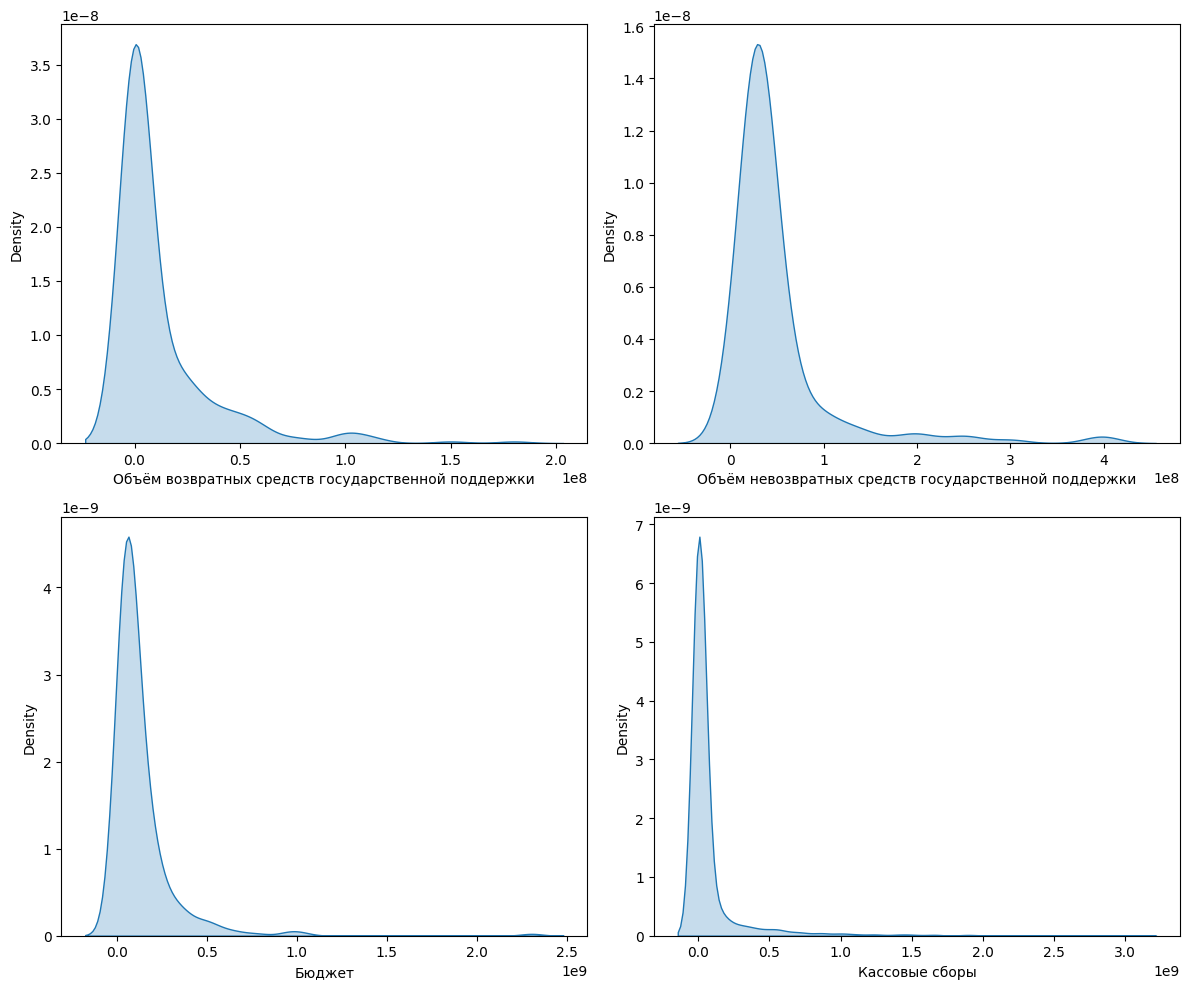

In [35]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

sns.kdeplot(df['refundable_support'], fill=True, ax=axes[0, 0])
axes[0, 0].set_xlabel('Объём возвратных средств государственной поддержки')

sns.kdeplot(df['nonrefundable_support'], fill=True, ax=axes[0, 1])
axes[0, 1].set_xlabel('Объём невозвратных средств государственной поддержки')

sns.kdeplot(df['budget'], fill=True, ax=axes[1, 0])
axes[1, 0].set_xlabel('Бюджет')

sns.kdeplot(df['box_office'], fill=True, ax=axes[1, 1])
axes[1, 1].set_xlabel('Кассовые сборы')

plt.tight_layout()
plt.show()

In [36]:
df[['refundable_support', 'nonrefundable_support', 'budget', 'box_office']].rename(columns={'refundable_support': 
'Объём возвратных средств', 'nonrefundable_support': 'Объём невозвратных средств', 'budget': 
'Бюджет', 'box_office': 'Кассовые сборы'}).describe()

,Объём возвратных средств,Объём невозвратных средств,Бюджет,Кассовые сборы
count,3.320000e+02,3.320000e+02,3.320000e+02,3.156000e+03
mean,1.186446e+07,4.898099e+07,1.272297e+08,7.652713e+07
std,2.491656e+07,5.998012e+07,1.885883e+08,2.404216e+08
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,0.000000e+00,2.500000e+07,4.200000e+07,8.744275e+04
50%,0.000000e+00,3.000000e+07,6.864992e+07,2.334077e+06
75%,1.500000e+07,4.037500e+07,1.419853e+08,2.398929e+07
max,1.800000e+08,4.000000e+08,2.305074e+09,3.073569e+09


In [37]:
df.loc[df['budget']>0].head(10)

,title,puNumber,show_start_date,type,film_studio,production_country,director,producer,age_restriction,refundable_support,nonrefundable_support,budget,financing_source,ratings,genres,box_office
1281,Пока еще жива,111005313,2013-10-11 12:00:00+00:00,Художественный,"АНО содействия развитию кинематографии ""Ангел-...",Россия,А.Атанесян,"А.Атанесян, М.Бабаханов, Р.Бутко",«16+» - для детей старше 16 лет,0.0,26500000.0,79411900.0,Министерство культуры,8.1,"драма,мелодрама",365353.6
1448,Бесславные придурки,111003314,2014-03-28 12:00:00+00:00,Художественный,"ООО ""Компания ""АТК-Студио""",Россия,А.Якимчук,А.Тютрюмов,«12+» - для детей старше 12 лет,0.0,26000000.0,37142857.0,Министерство культуры,NaN,неизвестно,28140.0
1498,Невидимки,111004213,2013-09-10 12:00:00+00:00,Художественный,"ООО ""Компания ""РЕАЛ-ДАКОТА""",Россия,"Р.Давлетьяров, С.Комаров","Р.Давлетьяров, А.Котелевский, А.Олейников",«12+» - для детей старше 12 лет,0.0,107847945.0,176023490.0,Фонд кино,5.3,"комедия,фантастика",19957031.5
1524,БЕРЦЫ,111004314,2014-05-05 12:00:00+00:00,Художественный,"ООО ""Студия ""Пассажир""",Россия,Е.Миндадзе (псевдоним Катя Шагалова),Л.Антонова,«16+» - для детей старше 16 лет,0.0,28000000.0,40574140.0,Министерство культуры,4.2,драма,55917.5
1792,Братья Ч,111004414,2014-04-23 12:00:00+00:00,Художественный,"ООО ""Студия ""Пассажир""",Россия,М.Угаров,"А.Миндадзе, Л.Антонова",«16+» - для детей старше 16 лет,0.0,25000000.0,40015122.0,Министерство культуры,6.4,драма,232100.0
1854,Тайна Сухаревой башни. Чародей равновесия,114000115,2015-02-18 12:00:00+00:00,Анимационный,"ООО ""Студия ""Мастер-Фильм""",Россия,С.Серегин,А.Герасимов,«6+» - для детей старше 6 лет,0.0,25000000.0,51850000.0,Министерство культуры,6.1,"мультфильм,фэнтези,история",15078858.6
1870,А зори здесь тихие..._,111002915,2015-03-16 12:00:00+00:00,Художественный,"ООО ""Компания ""Реал-Дакота""",Россия,Р.Давлетьяров,неизвестно,«12+» - для детей старше 12 лет,50000000.0,100000000.0,220588394.0,Фонд кино,8.5,"драма,военный,история",249166767.7
1871,Две женщины,111013714,2014-10-02 12:00:00+00:00,Художественный,"ООО ""Продюсерский Центр ""Хорошо Продакшн"", Rez...",Россия-Франция-Латвия,В.Глаголева,Н.Иванова,«12+» - для детей старше 12 лет,0.0,46502299.0,86210067.0,"Министерство культуры, Фонд кино",6.7,драма,4731239.5
1903,Призрак_.,111001815,2015-03-02 12:00:00+00:00,Художественный,"ООО ""Водород 2011""",Россия,А.Войтинский,С.Сельянов,«6+» - для детей старше 6 лет,0.0,75000000.0,139551503.0,Фонд кино,7.0,"триллер,боевик,приключения",352804320.4
1912,Ведьма .,111002215,2015-03-05 12:00:00+00:00,Художественный,"ООО ""Кинокомпания ""Ракурс""",Россия,Д.Федоров,В.Сидоренко,«16+» - для детей старше 16 лет,0.0,34000000.0,48571430.0,Министерство культуры,7.4,"фэнтези,приключения,драма",51907.5


После составления графиков и проверки ключевых показателей по столбцам доходов, расходов и общего бюджета фильмов, мы обнаружили, что бюджет во много раз превышает сумму возвратных и невозвратных средств. Вероятно, для фильмов, по которым мы имеем информацию о бюджете, также использовались дополнительные средства.

### Добавление новых столбцов

In [38]:
df['rental_year'] = df['show_start_date'].dt.year
df.head(10)

,title,puNumber,show_start_date,type,film_studio,production_country,director,producer,age_restriction,refundable_support,nonrefundable_support,budget,financing_source,ratings,genres,box_office,rental_year
0,Открытый простор,221048915,2015-11-27 12:00:00+00:00,Художественный,"Тачстоун Пикчерз, Кобальт Пикчерз, Бикон Пикче...",США,Кевин Костнер,"Дэвид Валдес, Кевин Костнер, Джейк Эбертс",«18+» - запрещено для детей,NaN,NaN,NaN,NaN,7.2,"боевик,драма,мелодрама",NaN,2015
1,Особо важное задание,111013716,2016-09-13 12:00:00+00:00,Художественный,"Киностудия ""Мосфильм""",СССР,Е.Матвеев,неизвестно,«6+» - для детей старше 6 лет,NaN,NaN,NaN,NaN,6.6,"драма,военный",NaN,2016
2,Особо опасен,221038416,2016-10-10 12:00:00+00:00,Художественный,"Юниверсал Пикчерз, Кикстарт Продакшнз, Марк Пл...",США,Тимур Бекмамбетов,"Джим Лемли, Джейсон Нетер, Марк Е.Платт, Яйн Смит",«18+» - запрещено для детей,NaN,NaN,NaN,NaN,6.8,"фантастика,боевик,триллер",NaN,2016
3,Особо опасен,221026916,2016-06-10 12:00:00+00:00,Художественный,"Юниверсал Пикчерз, Кикстарт Продакшнз, Марк Пл...",США,Тимур Бекмамбетов,"Джим Лемли, Джейсон Нетер, Марк Е.Платт, Яйн Смит",«18+» - запрещено для детей,NaN,NaN,NaN,NaN,6.8,"фантастика,боевик,триллер",NaN,2016
4,Особо опасен,221030815,2015-07-29 12:00:00+00:00,Художественный,"Юниверсал Пикчерз, Кикстарт Продакшнз, Марк Пл...",США,Тимур Бекмамбетов,"Джим Лемли, Джейсон Нетер, Марк Е.Платт, Яйн Смит",«18+» - запрещено для детей,NaN,NaN,NaN,NaN,6.8,"фантастика,боевик,триллер",NaN,2015
5,Остановился поезд,111013816,2016-09-13 12:00:00+00:00,Художественный,"Киностудия ""Мосфильм""",СССР,В.Абдрашитов,неизвестно,«6+» - для детей старше 6 лет,NaN,NaN,NaN,NaN,7.7,драма,NaN,2016
6,Любовь и голуби,111007013,2013-10-18 12:00:00+00:00,Художественный,"Киностудия ""Мосфильм""",СССР,В.Меньшов,неизвестно,«12+» - для детей старше 12 лет,NaN,NaN,NaN,NaN,8.3,"мелодрама,комедия",2700.0,2013
7,Любовь и сигареты,221074614,2014-12-29 12:00:00+00:00,Художественный,"Юнайтед Артистс, Грин Стрит Филмз, Айкон Интер...",США,Джон Туртурро,"Джон Пенотти, Джон Туртурро",«18+» - запрещено для детей,NaN,NaN,NaN,NaN,6.6,"мюзикл,мелодрама,комедия",NaN,2014
8,Отпетые мошенники.,121011416,2016-05-05 12:00:00+00:00,Художественный,"Пульсар Продюксьон, ТФ1 Фильм",Франция,Эрик Беснард,Патрис Леду,«18+» - запрещено для детей,NaN,NaN,NaN,NaN,8.0,"комедия,криминал",NaN,2016
9,Отпуск за свой счет,111019114,2014-12-01 12:00:00+00:00,Художественный,"Киностудия ""Мосфильм"", Телевидение ВНР",СССР-Венгрия,В.Титов,неизвестно,«12+» - для детей старше 12 лет,NaN,NaN,NaN,NaN,7.8,"мелодрама,комедия",NaN,2014


In [39]:
df['director_name'] = df['director'].str.split(",").str.get(0)
df['main_genre'] = df['genres'].str.split(",").str.get(0)
df.head(10)

,title,puNumber,show_start_date,type,film_studio,production_country,director,producer,age_restriction,refundable_support,nonrefundable_support,budget,financing_source,ratings,genres,box_office,rental_year,director_name,main_genre
0,Открытый простор,221048915,2015-11-27 12:00:00+00:00,Художественный,"Тачстоун Пикчерз, Кобальт Пикчерз, Бикон Пикче...",США,Кевин Костнер,"Дэвид Валдес, Кевин Костнер, Джейк Эбертс",«18+» - запрещено для детей,NaN,NaN,NaN,NaN,7.2,"боевик,драма,мелодрама",NaN,2015,Кевин Костнер,боевик
1,Особо важное задание,111013716,2016-09-13 12:00:00+00:00,Художественный,"Киностудия ""Мосфильм""",СССР,Е.Матвеев,неизвестно,«6+» - для детей старше 6 лет,NaN,NaN,NaN,NaN,6.6,"драма,военный",NaN,2016,Е.Матвеев,драма
2,Особо опасен,221038416,2016-10-10 12:00:00+00:00,Художественный,"Юниверсал Пикчерз, Кикстарт Продакшнз, Марк Пл...",США,Тимур Бекмамбетов,"Джим Лемли, Джейсон Нетер, Марк Е.Платт, Яйн Смит",«18+» - запрещено для детей,NaN,NaN,NaN,NaN,6.8,"фантастика,боевик,триллер",NaN,2016,Тимур Бекмамбетов,фантастика
3,Особо опасен,221026916,2016-06-10 12:00:00+00:00,Художественный,"Юниверсал Пикчерз, Кикстарт Продакшнз, Марк Пл...",США,Тимур Бекмамбетов,"Джим Лемли, Джейсон Нетер, Марк Е.Платт, Яйн Смит",«18+» - запрещено для детей,NaN,NaN,NaN,NaN,6.8,"фантастика,боевик,триллер",NaN,2016,Тимур Бекмамбетов,фантастика
4,Особо опасен,221030815,2015-07-29 12:00:00+00:00,Художественный,"Юниверсал Пикчерз, Кикстарт Продакшнз, Марк Пл...",США,Тимур Бекмамбетов,"Джим Лемли, Джейсон Нетер, Марк Е.Платт, Яйн Смит",«18+» - запрещено для детей,NaN,NaN,NaN,NaN,6.8,"фантастика,боевик,триллер",NaN,2015,Тимур Бекмамбетов,фантастика
5,Остановился поезд,111013816,2016-09-13 12:00:00+00:00,Художественный,"Киностудия ""Мосфильм""",СССР,В.Абдрашитов,неизвестно,«6+» - для детей старше 6 лет,NaN,NaN,NaN,NaN,7.7,драма,NaN,2016,В.Абдрашитов,драма
6,Любовь и голуби,111007013,2013-10-18 12:00:00+00:00,Художественный,"Киностудия ""Мосфильм""",СССР,В.Меньшов,неизвестно,«12+» - для детей старше 12 лет,NaN,NaN,NaN,NaN,8.3,"мелодрама,комедия",2700.0,2013,В.Меньшов,мелодрама
7,Любовь и сигареты,221074614,2014-12-29 12:00:00+00:00,Художественный,"Юнайтед Артистс, Грин Стрит Филмз, Айкон Интер...",США,Джон Туртурро,"Джон Пенотти, Джон Туртурро",«18+» - запрещено для детей,NaN,NaN,NaN,NaN,6.6,"мюзикл,мелодрама,комедия",NaN,2014,Джон Туртурро,мюзикл
8,Отпетые мошенники.,121011416,2016-05-05 12:00:00+00:00,Художественный,"Пульсар Продюксьон, ТФ1 Фильм",Франция,Эрик Беснард,Патрис Леду,«18+» - запрещено для детей,NaN,NaN,NaN,NaN,8.0,"комедия,криминал",NaN,2016,Эрик Беснард,комедия
9,Отпуск за свой счет,111019114,2014-12-01 12:00:00+00:00,Художественный,"Киностудия ""Мосфильм"", Телевидение ВНР",СССР-Венгрия,В.Титов,неизвестно,«12+» - для детей старше 12 лет,NaN,NaN,NaN,NaN,7.8,"мелодрама,комедия",NaN,2014,В.Титов,мелодрама


In [40]:
df['state_support'] = ((df['refundable_support'] + df['nonrefundable_support'])/df['budget']*100).round(2)
df.loc[df['state_support']>0]

,title,puNumber,show_start_date,type,film_studio,production_country,director,producer,age_restriction,refundable_support,nonrefundable_support,budget,financing_source,ratings,genres,box_office,rental_year,director_name,main_genre,state_support
1281,Пока еще жива,111005313,2013-10-11 12:00:00+00:00,Художественный,"АНО содействия развитию кинематографии ""Ангел-...",Россия,А.Атанесян,"А.Атанесян, М.Бабаханов, Р.Бутко",«16+» - для детей старше 16 лет,0.0,26500000.0,79411900.0,Министерство культуры,8.1,"драма,мелодрама",3.653536e+05,2013,А.Атанесян,драма,33.37
1448,Бесславные придурки,111003314,2014-03-28 12:00:00+00:00,Художественный,"ООО ""Компания ""АТК-Студио""",Россия,А.Якимчук,А.Тютрюмов,«12+» - для детей старше 12 лет,0.0,26000000.0,37142857.0,Министерство культуры,NaN,неизвестно,2.814000e+04,2014,А.Якимчук,неизвестно,70.00
1498,Невидимки,111004213,2013-09-10 12:00:00+00:00,Художественный,"ООО ""Компания ""РЕАЛ-ДАКОТА""",Россия,"Р.Давлетьяров, С.Комаров","Р.Давлетьяров, А.Котелевский, А.Олейников",«12+» - для детей старше 12 лет,0.0,107847945.0,176023490.0,Фонд кино,5.3,"комедия,фантастика",1.995703e+07,2013,Р.Давлетьяров,комедия,61.27
1524,БЕРЦЫ,111004314,2014-05-05 12:00:00+00:00,Художественный,"ООО ""Студия ""Пассажир""",Россия,Е.Миндадзе (псевдоним Катя Шагалова),Л.Антонова,«16+» - для детей старше 16 лет,0.0,28000000.0,40574140.0,Министерство культуры,4.2,драма,5.591750e+04,2014,Е.Миндадзе (псевдоним Катя Шагалова),драма,69.01
1792,Братья Ч,111004414,2014-04-23 12:00:00+00:00,Художественный,"ООО ""Студия ""Пассажир""",Россия,М.Угаров,"А.Миндадзе, Л.Антонова",«16+» - для детей старше 16 лет,0.0,25000000.0,40015122.0,Министерство культуры,6.4,драма,2.321000e+05,2014,М.Угаров,драма,62.48
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7464,Союз спасения,111022019,2019-12-26 12:00:00+00:00,Художественный,"ЗАО ""Дирекция кино""",Россия,А.Кравчук,"А.Максимов, К.Эрнст",«12+» - для детей старше 12 лет,100000000.0,400000000.0,980000000.0,Фонд кино,6.0,"история,биография,драма",7.177032e+08,2019,А.Кравчук,история,51.02
7466,Иван Царевич и Серый Волк 4,114005019,2019-12-20 12:00:00+00:00,Анимационный,"ООО ""Студия анимационного кино ""Мельница""",Россия,"Д.Шмидт, К.Феоктистов","С.Сельянов, А.Боярский",«6+» - для детей старше 6 лет,100000000.0,0.0,190000000.0,Фонд кино,6.7,"мультфильм,приключения,семейный",5.010692e+08,2019,Д.Шмидт,мультфильм,52.63
7474,Вторжение,111022519,2019-12-23 12:00:00+00:00,Художественный,"ООО ""Арт Пикчерс Студия"", ООО ""Водород 2011""",Россия,Ф.Бондарчук,"Ф.Бондарчук, М.Врубель, А.Андрющенко, Д.Рудовский",«12+» - для детей старше 12 лет,100000000.0,400000000.0,944000000.0,Фонд кино,5.7,"фантастика,боевик",NaN,2019,Ф.Бондарчук,фантастика,52.97
7476,Я свободен,111023019,2019-12-26 12:00:00+00:00,Художественный,"АО ""ТПО ""Киностудия им. М.Горького""",Россия,И.Северов,С.Зернов,«12+» - для детей старше 12 лет,0.0,30000000.0,46154000.0,Министерство культуры,5.9,драма,NaN,2019,И.Северов,драма,65.00


При предварительной обработке мы проверили типы данных и преобразовали некоторые из них там, где это было необходимо. Мы также изучили и заполнили пропущенные значения, объяснив, почему использовали те или иные способы для заполнения.
Мы исследовали явные и скрытые дубликаты и описали возможные причины их появления. Кроме того, мы изучили категориальные значения и обнаружили общую проблему, встречающуюся в большинстве столбцов — пробелы в названиях.
Далее мы проанализировали количественные данные и создали их графики. Наконец, мы добавили три новых столбца с информацией о годе выпуска, имени и фамилии режиссера и основном жанре фильма, а также выяснили, какую долю от общего бюджета составляла государственная поддержка.

## Исследовательский анализ данных

In [41]:
fpy = df.groupby('rental_year')['show_start_date'].count()
fpy_perc = round((df.groupby('rental_year')['box_office'].count()/df.groupby('rental_year')['show_start_date'].count())*100,2)
display(pd.DataFrame({'Количество фильмов':fpy,'% фильмов в прокате':fpy_perc}).style.format('{:.2f}').background_gradient('Pastel2'))

,Количество фильмов,% фильмов в прокате
rental_year,,
2010,978.00,10.74
2011,620.00,17.58
2012,592.00,21.45
2013,629.00,29.25
2014,806.00,34.62
2015,705.00,65.96
2016,818.00,64.30
2017,505.00,70.69
2018,879.00,53.92


<Axes: title={'center': 'Количество фильмов в год'}, xlabel='rental_year'>

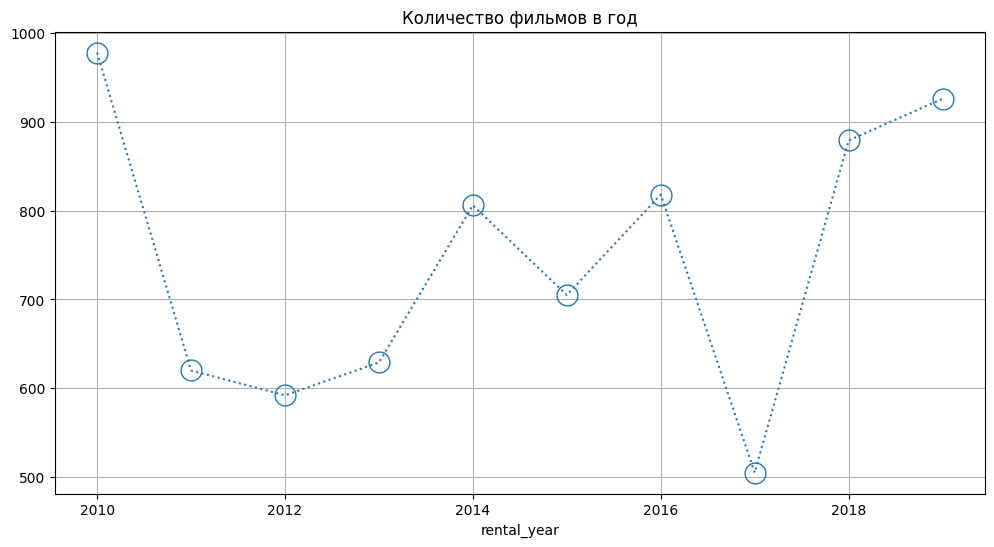

In [42]:
df = df.rename(columns = {'puNumber':'pu_number'})
df.groupby('rental_year')['show_start_date'].count().plot(title = 'Количество фильмов в год', 
figsize = (12, 6), ls=":", marker = "o", markersize = 15, markerfacecolor = "None", grid = True)

In [43]:
print("Доля фильмов с указанной информацией о прокате в кинотеатрах составляет:",  
round((df['box_office'].count() / df['show_start_date'].count()) * 100, 2))

Доля фильмов с указанной информацией о прокате в кинотеатрах составляет: 42.32


Исходя из полученных данных, мы видим, что начиная с 2015 года, процент фильмов в прокате ни разу не опускался ниже 54% от общего числа выпущенных фильмов за данный год. При этом, наибольший процент фильмов в прокате пришелся на 2017 год - 70,69%, в то время как наименьший - на 2010 год и составил 10,74%.

In [44]:
box_office_sum = df.groupby('rental_year')['box_office'].sum()
display(pd.DataFrame({'Сумма кассового сбора':box_office_sum}).style.format('{:.0f}').background_gradient('Pastel2'))

,Сумма кассового сбора
rental_year,
2010,2428654
2011,14102765
2012,6911073
2013,29799706
2014,7444951859
2015,39497365196
2016,47866299742
2017,48563707218
2018,49668361909


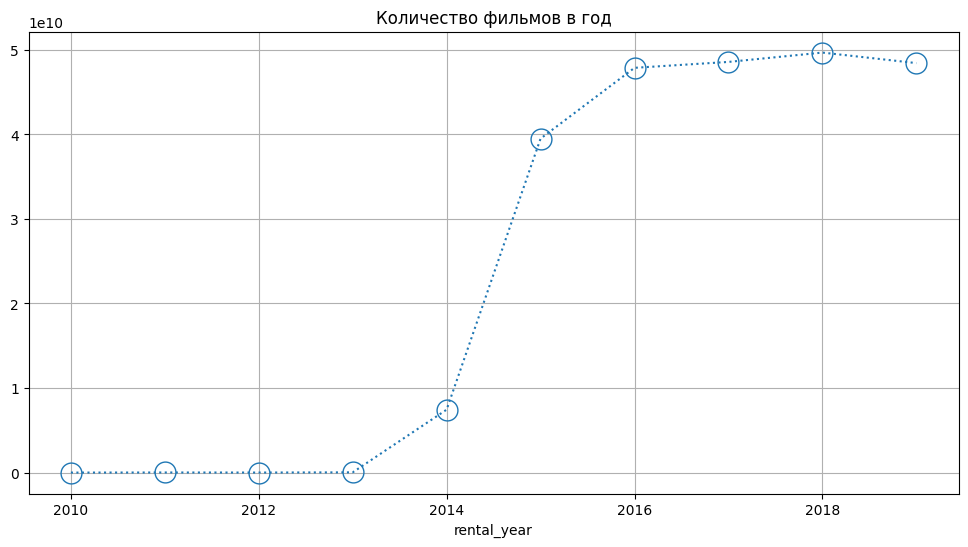

In [45]:
box_office_sum = df.groupby('rental_year')['box_office'].sum().plot(title = 'Количество фильмов в год', 
figsize = (12, 6), ls = ":", marker = "o", markersize = 15, markerfacecolor = "None", grid = True)

После группировки данных, мы получили таблицу, из которой следует, что наименьшая сумма сборов была в 2010 году, а наибольшая - в 2018 году.

In [46]:
mean_median = df.pivot_table(index = 'rental_year', values = 'box_office', aggfunc = ['mean', 'median']).round()
mean_median.columns = ['Средняя', 'Медиана']
display(pd.DataFrame(mean_median).style.format('{:.0f}').background_gradient('Pastel2'))

,Средняя,Медиана
rental_year,,
2010,23130,1700
2011,129383,3000
2012,54418,5560
2013,161955,3522
2014,26684415,18160
2015,84940570,4920933
2016,91000570,3846679
2017,136032793,9968340
2018,104785574,8911534


In [47]:
dependence = df.loc[df['rental_year'] > 2014]
arb = dependence.groupby('age_restriction')['box_office'].sum()
display(pd.DataFrame({'Сумма кассового сбора': arb}).style.format('{:.0f}').background_gradient('Pastel2'))

,Сумма кассового сбора
age_restriction,
«0+» - для любой зрительской аудитории,809077426
«12+» - для детей старше 12 лет,60619405403
«16+» - для детей старше 16 лет,76034733644
«18+» - запрещено для детей,40759615572
«6+» - для детей старше 6 лет,55798610800


<Axes: title={'center': 'Сумма кассового сбора по возрастному ограничению'}, xlabel='age_restriction'>

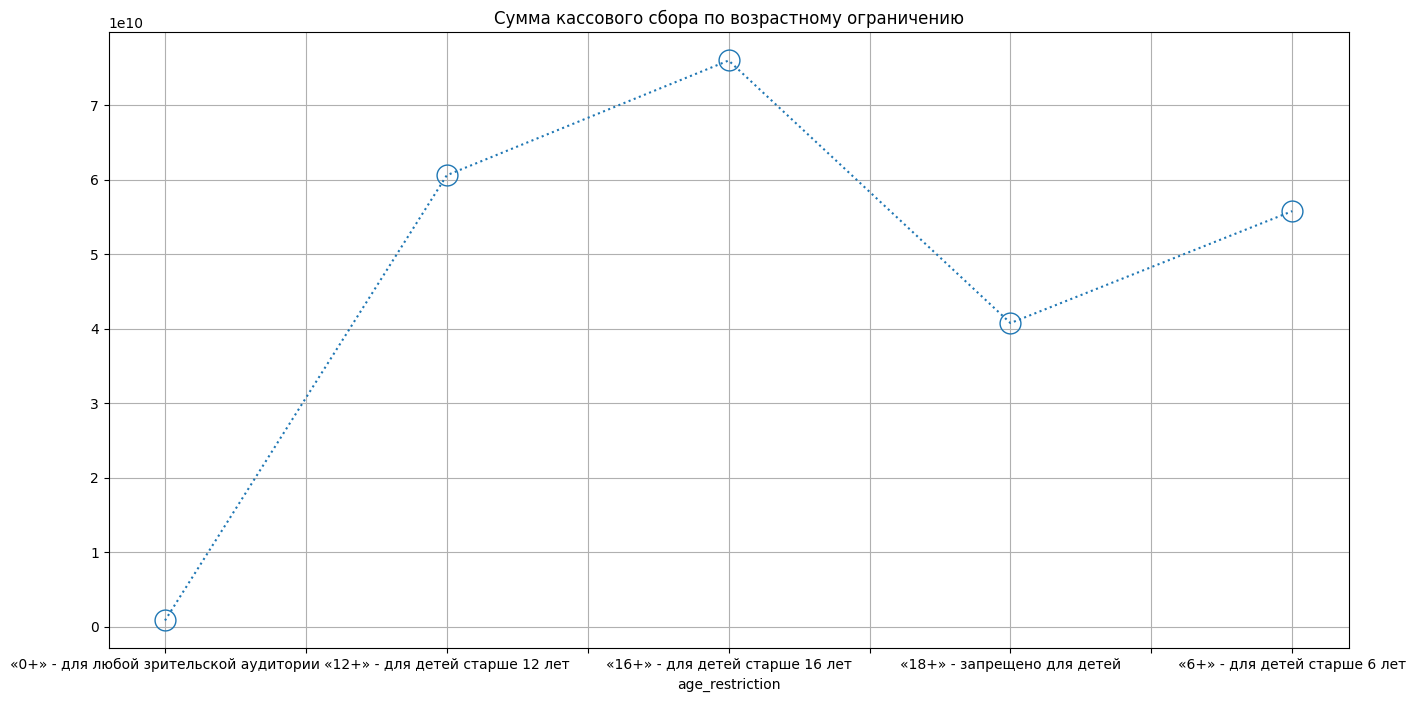

In [48]:
arb.plot(title = 'Сумма кассового сбора по возрастному ограничению', figsize = (16, 8), ls = ":", marker = "o", 
markersize = 15, markerfacecolor = "None", grid = True)

In [49]:
spy = dependence.pivot_table(index = 'age_restriction', columns = 'rental_year', values = 'box_office', aggfunc = ['count', 'sum']).round()

spy.columns = pd.MultiIndex.from_tuples([('Количество фильмов', '2015'), ('Количество фильмов', '2016'), ('Количество фильмов', '2017'), 
('Количество фильмов', '2018'), ('Количество фильмов', '2019'), ('Сумма сборов', '2015'), ('Сумма сборов', '2016'), 
('Сумма сборов', '2017'), ('Сумма сборов', '2018'), ('Сумма сборов', '2019')])

display(pd.DataFrame(spy).style.format('{:.0f}').background_gradient(cmap = 'Pastel2'))


In [50]:
spy = dependence.pivot_table(index = 'age_restriction', columns = 'rental_year', values = 'box_office', aggfunc = 'median').round()
display(pd.DataFrame(spy).style.format('{:.0f}').background_gradient('Pastel2'))

rental_year,2015,2016,2017,2018,2019
age_restriction,,,,,
«0+» - для любой зрительской аудитории,2943319,2571294,22178956,3616937,3885434
«12+» - для детей старше 12 лет,15351562,4690635,9010548,10035323,3405546
«16+» - для детей старше 16 лет,4676819,5133022,9702077,9010639,3210718
«18+» - запрещено для детей,4616615,6107002,8212677,7179466,5603217
«6+» - для детей старше 6 лет,20380982,3026256,51992103,14688850,12875350


Сумма сборов не прямо пропорционально зависит от возрастной категории зрителей. Наблюдается постепенное увеличение сборов от категории “0+” до “16+”, однако в категории “18+” сумма сборов снижается. Вероятно, это связано с тем, что аудитория фильмов для взрослых в меньшей степени представлена детской и подростковой аудиторией. В целом, за период с 2015 по 2019 года, наибольшие сборы имели фильмы категории “16+”. С другой стороны, сборы в категории “0+” были минимальными, что может указывать на то, что родители предпочитают не водить совсем маленьких детей на фильмы, предназначенные для более старшей аудитории.

## Исследование фильмов, которые получили государственную поддержку

In [51]:
# создадим таблицы с рейтингом, объемом возвратных и невозвратных госсредств по различным категориям
# преобразуем столбец "ratings" в числовой формат

df['ratings'] = pd.to_numeric(df['ratings'], errors='coerce')

rrn = df.pivot_table(index='rental_year', values=['refundable_support', 'nonrefundable_support', 'ratings'], aggfunc={'refundable_support':'sum', 'nonrefundable_support':'sum', 'ratings':'mean'}).round()
rrn.columns = ['Объём возвратных средств', 'Рейтинг', 'Объём невозвратных средств']

trn = df.pivot_table(index='type', values=['refundable_support', 'nonrefundable_support', 'ratings'], aggfunc={'refundable_support':'sum', 'nonrefundable_support':'sum', 'ratings':'mean'}).round()
trn.columns = ['Объём возвратных средств', 'Рейтинг', 'Объём невозвратных средств']

arn = df.pivot_table(index='age_restriction', values=['refundable_support', 'nonrefundable_support', 'ratings'], aggfunc={'refundable_support':'sum', 'nonrefundable_support':'sum', 'ratings':'mean'}).round()
arn.columns = ['Объём возвратных средств', 'Рейтинг', 'Объём невозвратных средств']

prn = df.pivot_table(index='production_country', values=['refundable_support', 'nonrefundable_support', 'ratings'], aggfunc={'refundable_support':'sum', 'nonrefundable_support':'sum', 'ratings':'mean'}).round()
prn = prn.loc[prn['nonrefundable_support'] > 0]
prn.columns = ['Объём возвратных средств', 'Рейтинг', 'Объём невозвратных средств']

frn = df.pivot_table(index='financing_source', values=['refundable_support', 'nonrefundable_support', 'ratings'], aggfunc={'refundable_support':'sum', 'nonrefundable_support':'sum', 'ratings':'mean'}).round()
frn.columns = ['Объём возвратных средств', 'Рейтинг', 'Объём невозвратных средств']

table = pd.concat([rrn, trn, arn, prn, frn], keys=['По году проката', 'По типу фильма', 'По возрастной категории', 'По стране-производителю', 'По источнику госфинансирования'])

display(pd.DataFrame(table).style.format('{:.0f}').background_gradient(cmap='Pastel2'))

## Общий вывод

- В ходе исследования были проанализированы данные о сборах и поддержке киноиндустрии. Было выявлено, что количество выпускаемых фильмов растет каждый год, что способствует увеличению сумм сборов. В то же время, поддержка киноиндустрии значительно выросла к 2018 году, что может свидетельствовать о растущей популярности кино.


- Однако, анализ окупаемости фильмов показал, что не все категории приносят прибыль. Например, возрастная категория 16+ в 2019 году была убыточной, а категория 6+ имела наибольший убыток. Это может свидетельствовать о том, что необходимо внимательнее выбирать категории фильмов для поддержки.


- Проделанная работа по анализу данных о выпусках и сборах фильмов позволила получить некоторые интересные закономерности и зависимости. Было выявлено, что количество выпускаемых фильмов в год колеблется, а динамика кассовых сборов не стабильна. Удалось установить, что средний кассовый сбор фильмов в год значительно варьируется, с преобладающим большинством фильмов, собирающих сбор ниже среднего. Кроме того, было определено, что возрастные рейтинги фильмов могут влиять на кассовые сборы, хотя это влияние не всегда однозначно. Также была определена зависимость успешности фильмов от источников финансирования и их рейтинг.